<a href="https://colab.research.google.com/github/ashishkdeshmukh31/LPV_DL/blob/main/DL1_BostonHousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense

In [5]:
from google.colab import files
uploaded = files.upload()

Saving housing.csv to housing.csv


In [6]:
df = pd.read_csv('housing.csv')
df.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [7]:
df.tail()

,RM,LSTAT,PTRATIO,MEDV
484,6.593,9.67,21.0,470400.0
485,6.120,9.08,21.0,432600.0
486,6.976,5.64,21.0,501900.0
487,6.794,6.48,21.0,462000.0
488,6.030,7.88,21.0,249900.0


In [8]:
df.isnull().sum()

,0
RM,0
LSTAT,0
PTRATIO,0
MEDV,0


In [10]:
df.describe()

,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


<Axes: >

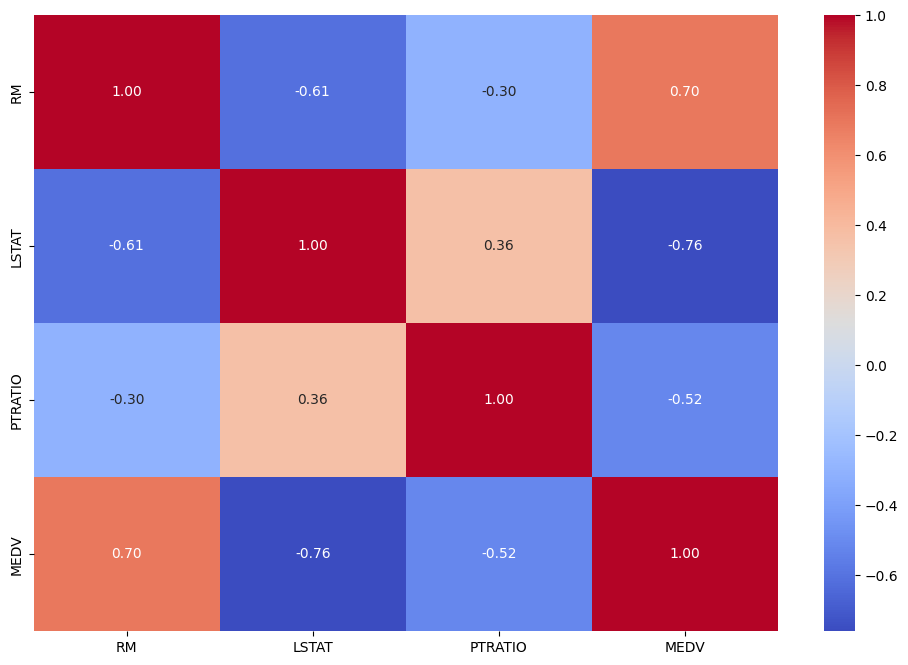

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")

In [13]:
print(df.columns)

Index(['RM', 'LSTAT', 'PTRATIO', 'MEDV'], dtype='object')


In [14]:
x = df[['LSTAT', 'PTRATIO', 'RM']]
y = df['MEDV']

x.shape, y.shape

((489, 3), (489,))

In [15]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.20, random_state=42
)

In [16]:
sc = StandardScaler()
sc.fit(xtrain)
xtrain = sc.transform(xtrain)
xtest = sc.transform(xtest)

In [17]:
model = Sequential()

In [18]:
model.add(Dense(128, input_shape=(3,), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.fit(xtrain, ytrain, epochs=100, validation_split=0.05)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 241979146240.0000 - mae: 462316.6875 - val_loss: 233723691008.0000 - val_mae: 451394.1875
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 241978245120.0000 - mae: 462315.7188 - val_loss: 233722707968.0000 - val_mae: 451393.1875
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 241977065472.0000 - mae: 462314.4688 - val_loss: 233721200640.0000 - val_mae: 451391.6875
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 241975115776.0000 - mae: 462312.5312 - val_loss: 233718857728.0000 - val_mae: 451389.3438
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 241972297728.0000 - mae: 462309.6562 - val_loss: 233715351552.0000 - val_mae: 451385.9062
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 241967972352.0000 - mae: 462305.3438 - val_loss: 233710288896.0000 - val_mae: 451380.9375
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 241961975808.0000 - mae: 462299.3438 - v

In [20]:
output = model.evaluate(xtest, ytest)
print(f"Mean Squared Error: {output[0]}")
print(f"Mean Absolute Error: {output[1]}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 151706877952.0000 - mae: 368250.8438
Mean Squared Error: 151706877952.0
Mean Absolute Error: 368250.84375


In [21]:
model = Sequential()
model.add(Dense(128, input_shape=(3,), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,881 (42.50 KB)

 Trainable params: 10,881 (42.50 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.fit(xtrain, ytrain, epochs=100, validation_split=0.05)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 241979146240.0000 - mae: 462316.5625 - val_loss: 233723658240.0000 - val_mae: 451394.1562
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 241978130432.0000 - mae: 462315.5000 - val_loss: 233722167296.0000 - val_mae: 451392.5938
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 241975885824.0000 - mae: 462313.1875 - val_loss: 233718808576.0000 - val_mae: 451389.0625
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 241970987008.0000 - mae: 462308.1250 - val_loss: 233711812608.0000 - val_mae: 451381.9375
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 241961320448.0000 - mae: 462298.0938 - val_loss: 233697935360.0000 - val_mae: 451368.0000
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 241942691840.0000 - mae: 462278.8438 - val_loss: 233672589312.0000 - val_mae: 451342.6875
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 241909186560.0000 - mae: 462245.0938 - val

In [23]:
output = model.evaluate(xtest, ytest)
print(f"Mean Squared Error: {output[0]}")
print(f"Mean Absolute Error: {output[1]}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 7793740288.0000 - mae: 62184.6875 
Mean Squared Error: 7793740288.0
Mean Absolute Error: 62184.6875


In [24]:
model = Sequential()
model.add(Dense(128, input_shape=(3,), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.fit(xtrain, ytrain, epochs=100, validation_split=0.05)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 241979080704.0000 - mae: 462316.5625 - val_loss: 233723707392.0000 - val_mae: 451394.1875
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 241978146816.0000 - mae: 462315.6562 - val_loss: 233722265600.0000 - val_mae: 451392.6875
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 241975803904.0000 - mae: 462313.1875 - val_loss: 233718415360.0000 - val_mae: 451388.9062
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 241969676288.0000 - mae: 462306.9375 - val_loss: 233709076480.0000 - val_mae: 451379.5938
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 241955127296.0000 - mae: 462292.3438 - val_loss: 233687842816.0000 - val_mae: 451358.6875
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 241924440064.0000 - mae: 462261.3438 - val_loss: 233643130880.0000 - val_mae: 451315.2500
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 241861459968.0000 - mae: 462198.2500 - val_lo

In [26]:
output = model.evaluate(xtest, ytest)
print(f"Mean Squared Error: {output[0]}")
print(f"Mean Absolute Error: {output[1]}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5808271872.0000 - mae: 56742.7617
Mean Squared Error: 5808271872.0
Mean Absolute Error: 56742.76171875


In [27]:
model = Sequential()
model.add(Dense(128, input_shape=(3,), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.fit(xtrain, ytrain, epochs=100, validation_split=0.05)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 241979408384.0000 - mae: 462316.9062 - val_loss: 233724280832.0000 - val_mae: 451394.7500
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 241979015168.0000 - mae: 462316.5625 - val_loss: 233723625472.0000 - val_mae: 451394.0938
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 241977884672.0000 - mae: 462315.2500 - val_loss: 233721593856.0000 - val_mae: 451392.0000
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 241974509568.0000 - mae: 462311.8125 - val_loss: 233716105216.0000 - val_mae: 451386.3438
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 241965596672.0000 - mae: 462302.7188 - val_loss: 233701933056.0000 - val_mae: 451372.0625
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 241943478272.0000 - mae: 462280.2812 - val_loss: 233668263936.0000 - val_mae: 451338.3125
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 241893408768.0000 - mae: 462229.5312 - val_

In [29]:
output = model.evaluate(xtest, ytest)
print(f"Mean Squared Error: {output[0]}")
print(f"Mean Absolute Error: {output[1]}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5523531776.0000 - mae: 55569.4297
Mean Squared Error: 5523531776.0
Mean Absolute Error: 55569.4296875


In [30]:
model = Sequential()
model.add(Dense(256, input_shape=(3,), activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,929 (175.50 KB)

 Trainable params: 44,929 (175.50 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.fit(xtrain, ytrain, epochs=100, validation_split=0.05)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 241978982400.0000 - mae: 462316.4688 - val_loss: 233723101184.0000 - val_mae: 451393.5938
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 241976279040.0000 - mae: 462313.5625 - val_loss: 233717399552.0000 - val_mae: 451387.7500
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 241964335104.0000 - mae: 462301.1250 - val_loss: 233693822976.0000 - val_mae: 451363.9062
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 241917558784.0000 - mae: 462253.8750 - val_loss: 233605005312.0000 - val_mae: 451275.6562
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 241755455488.0000 - mae: 462090.4062 - val_loss: 233311993856.0000 - val_mae: 450988.8125
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 241247272960.0000 - mae: 461584.4375 - val_loss: 232441069568.0000 - val_mae: 450147.4062
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 239810740224.0000 - mae: 460160.8125 - val_los

In [32]:
output = model.evaluate(xtest, ytest)
print(f"Mean Squared Error: {output[0]}")
print(f"Mean Absolute Error: {output[1]}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4863442944.0000 - mae: 53118.7383
Mean Squared Error: 4863442944.0
Mean Absolute Error: 53118.73828125
